# Lab 4: Model-Based Offline Optimization

In this lab, we explore **Model-Based Offline Optimization (MBO)**, a method to optimize black-box functions using only a pre-collected dataset, without additional function evaluations. We'll use two functions from the **Black-Box Optimization Benchmarking (BBOB)** suite:
- **f1** [Sphere Function](https://numbbo.github.io/gforge/downloads/download16.00/bbobdocfunctions.pdf#page=5): A simple, unimodal function with a global minimum at (0, 0).
- **f22** [Gallagher's Gaussian 21-hi Peaks Function](https://numbbo.github.io/gforge/downloads/download16.00/bbobdocfunctions.pdf#page=110): A complex, multimodal function with many local optima.

Visualizations of these problems are available [here](https://coco-platform.org/testsuites/bbob/viz.html?col=3&dim=2&fun=1&ins=1&typ=all).

### Objectives
1. **Dataset:** Use pre-collected datasets (100k samples each) for f1 and f22, generated via **Latin Hypercube Sampling (LHS)** [learn more about LHS here](https://en.wikipedia.org/wiki/Latin_hypercube_sampling).
2. **Surrogate Model:** Train a Multi-Layer Perceptron (MLP) to approximate these functions.
3. **Visualization:** Compare the MLP's predictions to the true functions using contour and scatter plots.
4. **Optimization:** Implement gradient-based optimization on the MLP to find optimal points.
5. **Experiments:** Investigate how training dataset size and model complexity affect performance.

### Key Concepts
- **Offline Optimization:** No new evaluations of the true function are allowed; we rely solely on the dataset.
- **Surrogate Model:** The MLP acts as a cheap, differentiable proxy for the expensive black-box function.
- **Gradient-Based Optimization:** Use the MLP's gradients to find optimal designs efficiently.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available() else "cpu"
)

### 1. Data Preparation

We start by loading and splitting the dataset into training, validation, and test sets.

In [3]:
def prepare_dataloaders(
    file_path: str,
    batch_size: int = 256,
    train_perc: float = 0.6,
    val_perc: float = 0.2,
) -> tuple[DataLoader, DataLoader, DataLoader]:
    """
    Prepare train, validation and test dataloaders.

    Args:
        file_path: Path to CSV data file
        batch_size: Batch size for dataloaders
        train_perc: Percentage of data for training
        val_perc: Percentage of data for validation
    """
    # Load data
    data_df = pd.read_csv(file_path)
    X = torch.tensor(data_df[["x1", "x2"]].values, dtype=torch.float32)
    y = torch.tensor(data_df["y"].values.reshape(-1, 1), dtype=torch.float32)

    # Split data
    num_samples = len(X)
    indices = np.random.permutation(num_samples)
    train_size = int(train_perc * num_samples)
    val_size = int(val_perc * num_samples)

    # Create datasets
    train_dataset = TensorDataset(X[indices[:train_size]], y[indices[:train_size]])
    val_dataset = TensorDataset(
        X[indices[train_size : train_size + val_size]],
        y[indices[train_size : train_size + val_size]],
    )
    test_dataset = TensorDataset(
        X[indices[train_size + val_size :]], y[indices[train_size + val_size :]]
    )

    # Create dataloaders
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataloader = DataLoader(val_dataset, batch_size=batch_size)
    test_dataloader = DataLoader(test_dataset, batch_size=batch_size)

    return train_dataloader, val_dataloader, test_dataloader

# Example usage (replace with your file path)
train_dataloader, val_dataloader, test_dataloader = prepare_dataloaders(
    "./bbob_f022_i01_d02_samples.csv", train_perc=0.3, val_perc=0.4
)

### 2. Define the MLP Model

The MLP will serve as our surrogate model to approximate the black-box function.

In [4]:
class MLP(nn.Module):
    def __init__(
        self, input_dim: int = 2, hidden_dim: int = 256, n_layers: int = 3
    ) -> None:
        """
        Multi-Layer Perceptron (MLP) for function approximation.

        Args:
            input_dim (int): Number of input features (e.g., 2 for x1, x2).
            hidden_dim (int): Number of neurons in each hidden layer.
            n_layers (int): Total number of layers (input + hidden + output).
        """
        super(MLP, self).__init__()

        layers = []
        # Input layer
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.ReLU())

        # Hidden layers
        for _ in range(n_layers - 2):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.ReLU())

        # Output layer -> 1 output neuron (regression, single-objective problem)
        layers.append(nn.Linear(hidden_dim, 1))

        self.model = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)

### 3. Training the Model

We train the MLP using the Adam optimizer and Mean Squared Error (MSE) loss.

In [5]:
model = MLP().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 100

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    for inputs, targets in train_dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * inputs.size(0)

    train_loss = train_loss / len(train_dataloader.dataset)
    train_losses.append(train_loss)
    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item() * inputs.size(0)
    val_loss = val_loss / len(val_dataloader.dataset)
    val_losses.append(val_loss)
    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}"
        )

model.eval()
test_loss = 0.0
with torch.no_grad():
    for inputs, targets in test_dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        test_loss += loss.item() * inputs.size(0)

test_loss = test_loss / len(test_dataloader.dataset)
print(f"Test Loss: {test_loss:.4f}")

Epoch 10/100, Train Loss: 446.7819, Val Loss: 420.1235
Epoch 20/100, Train Loss: 287.4273, Val Loss: 285.1097
Epoch 30/100, Train Loss: 234.2369, Val Loss: 234.2766
Epoch 40/100, Train Loss: 208.3357, Val Loss: 205.5962
Epoch 50/100, Train Loss: 188.9601, Val Loss: 190.4234
Epoch 60/100, Train Loss: 174.4364, Val Loss: 172.2464
Epoch 70/100, Train Loss: 165.5056, Val Loss: 160.8441
Epoch 80/100, Train Loss: 158.5658, Val Loss: 162.0961
Epoch 90/100, Train Loss: 149.5206, Val Loss: 144.6576
Epoch 100/100, Train Loss: 142.3593, Val Loss: 145.2876
Test Loss: 144.2619


### 4. Visualization

Let's visualize how well the MLP approximates the true function.

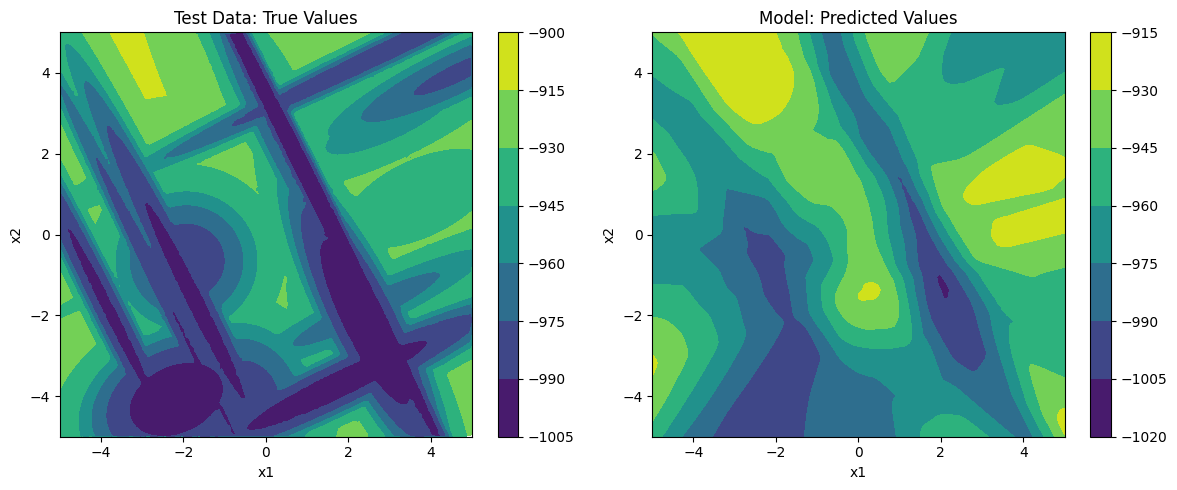

In [6]:
def plot_contour_comparison(
    model: nn.Module, test_dataloader: DataLoader, device: torch.device
) -> None:
    test_inputs_list = []
    test_targets_list = []

    for inputs, targets in test_dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        test_inputs_list.append(inputs.cpu().numpy())
        test_targets_list.append(targets.cpu().numpy())

    test_inputs = np.vstack(test_inputs_list)
    test_targets = np.concatenate(test_targets_list)

    x1_min, x1_max = test_inputs[:, 0].min(), test_inputs[:, 0].max()
    x2_min, x2_max = test_inputs[:, 1].min(), test_inputs[:, 1].max()
    x1_vals = np.linspace(x1_min, x1_max, 100)
    x2_vals = np.linspace(x2_min, x2_max, 100)
    X1, X2 = np.meshgrid(x1_vals, x2_vals)

    grid_points = np.column_stack((X1.flatten(), X2.flatten()))
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32, device=device)

    model.eval()
    with torch.no_grad():
        predictions = model(grid_tensor).cpu().numpy().flatten()

    Z_pred = predictions.reshape(X1.shape)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    true_contour = ax1.tricontourf(
        test_inputs[:, 0], test_inputs[:, 1], test_targets.reshape(-1)
    )
    ax1.set_title("Test Data: True Values")
    ax1.set_xlabel("x1")
    ax1.set_ylabel("x2")
    plt.colorbar(true_contour, ax=ax1)

    pred_contour = ax2.contourf(X1, X2, Z_pred)
    ax2.set_title("Model: Predicted Values")
    ax2.set_xlabel("x1")
    ax2.set_ylabel("x2")
    plt.colorbar(pred_contour, ax=ax2)

    plt.tight_layout()
    plt.show()

plot_contour_comparison(model, test_dataloader, device)

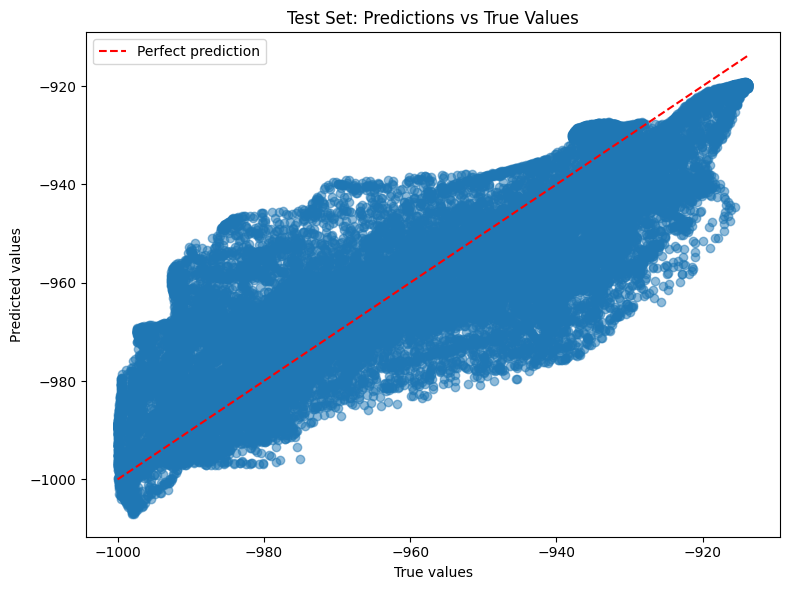

In [7]:
def plot_prediction_scatter(
    model: nn.Module, test_dataloader: DataLoader, device: torch.device
) -> None:
    test_targets_list = []
    test_preds_list = []

    for inputs, targets in test_dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        with torch.no_grad():
            outputs = model(inputs)

        test_targets_list.append(targets.cpu().numpy())
        test_preds_list.append(outputs.cpu().numpy())

    test_targets = np.concatenate(test_targets_list)
    test_preds = np.concatenate(test_preds_list).flatten()

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(test_targets, test_preds, alpha=0.5)
    ax.plot(
        [test_targets.min(), test_targets.max()],
        [test_targets.min(), test_targets.max()],
        "r--",
        label="Perfect prediction",
    )
    ax.set_xlabel("True values")
    ax.set_ylabel("Predicted values")
    ax.set_title("Test Set: Predictions vs True Values")
    ax.legend()

    plt.tight_layout()
    plt.show()


plot_prediction_scatter(model, test_dataloader, device)

### 5. Gradient-Based Optimization

Now, we optimize the trained MLP to find the input that minimizes its output (our surrogate's prediction).

In [21]:
from torch.optim import Adam
from torch.nn import CrossEntropyLoss

def optimize_model(
    model: nn.Module, num_steps: int = 1000
) -> tuple[torch.Tensor, float]:
    """
    Perform gradient-based optimization on the MLP.

    Args:
        model (nn.Module): Trained MLP model.
        num_steps (int): Number of optimization steps.

    Returns:
        tuple: (best_x, best_y) - Optimal input and its predicted output.
    """
    model.eval()
    # Select random starting point in [-5, 5]^2
    x = torch.rand(1, 2, device=device) * 10 - 5
    x.requires_grad_(True)
    optimizer = Adam([x])

    with torch.no_grad():
        best_y = model(x).clone()
    best_x = x.detach().clone()

    for _ in range(num_steps):
        optimizer.zero_grad()
        # Predict output (our output - result of the model is the function we want to minimize)
        # Compute gradients (gradients of our model)
        # Update x
        # Enforce domain constraints [-5, 5]
        y = model(x)
        y.backward()
        optimizer.step()
        x.data.clamp_(-5, 5)

        if y.item() < best_y.item():
            best_x = x.detach().clone()
            best_y = y.detach().clone()

    return best_x, best_y

### Exercise 1: Impact of Dataset Size
- **Task:** Train the MLP with different training set sizes (e.g., 100, 1000, 5000, 10000, 50000).
- **Instructions:**
  1. Modify the `train_perc` parameter in `prepare_dataloaders` to achieve these different dataset sizes (keep the test set size fixed at approximately 30,000 samples).
  2. Train the model for each dataset size and generate corresponding contour plots.
  3. Analyze how the MLP's ability to capture the underlying function structure (particularly the multimodal nature of f22) improves with increasing data volume.
  4. Select and justify a single quantitative metric that effectively captures the model’s predictive quality in this context. Use this metric to evaluate model performance across different training set sizes. Present the results as a plot to visualize how model quality scales with data availability.

In [9]:
def train_model(
    train_dataloader: DataLoader,
    val_dataloader: DataLoader,
    test_dataloader: DataLoader,
    lr: float = 0.001
  ):
  model = MLP().to(device)
  criterion = nn.MSELoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=lr)

  num_epochs = 100

  train_losses = []
  val_losses = []

  for epoch in range(num_epochs):
      # Training phase
      model.train()
      train_loss = 0.0
      for inputs, targets in train_dataloader:
          inputs, targets = inputs.to(device), targets.to(device)
          optimizer.zero_grad()
          outputs = model(inputs)
          loss = criterion(outputs, targets)
          loss.backward()
          optimizer.step()
          train_loss += loss.item() * inputs.size(0)

      train_loss = train_loss / len(train_dataloader.dataset)
      train_losses.append(train_loss)
      # Validation phase
      model.eval()
      val_loss = 0.0
      with torch.no_grad():
          for inputs, targets in val_dataloader:
              inputs, targets = inputs.to(device), targets.to(device)
              outputs = model(inputs)
              loss = criterion(outputs, targets)
              val_loss += loss.item() * inputs.size(0)
      val_loss = val_loss / len(val_dataloader.dataset)
      val_losses.append(val_loss)
      if (epoch + 1) % 10 == 0:
          print(
              f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}"
          )

  model.eval()
  test_loss = 0.0
  with torch.no_grad():
      for inputs, targets in test_dataloader:
          inputs, targets = inputs.to(device), targets.to(device)
          outputs = model(inputs)
          loss = criterion(outputs, targets)
          test_loss += loss.item() * inputs.size(0)

  test_loss = test_loss / len(test_dataloader.dataset)
  print(f"Test Loss: {test_loss:.4f}")

  return model, train_losses, val_losses, test_loss

In [10]:
TOTAL_SAMPLES = 100_000
train_samples_values = [100, 1_000, 5_000, 10_000, 50_000]
train_perc_values = [value / TOTAL_SAMPLES for value in train_samples_values]

In [11]:
models = []
train_losses_history = []
val_losses_history = []
test_loss_history = []
train_dataloader_history = []
val_dataloader_history = []
test_dataloader_history = []

for train_perc in train_perc_values:
  print(f"Training with train_per={train_perc}")
  _train_dataloader, _val_dataloader, _test_dataloader = prepare_dataloaders(
    "./bbob_f022_i01_d02_samples.csv", train_perc=train_perc, val_perc=0.7-train_perc
  )

  _model, _train_losses, _val_losses, _test_loss = train_model(
      _train_dataloader, _val_dataloader, _test_dataloader
  )


  train_dataloader_history.append(_train_dataloader)
  val_dataloader_history.append(_val_dataloader)
  test_dataloader_history.append(_test_dataloader)
  models.append(_model)
  train_losses_history.append(_train_losses)
  val_losses_history.append(_val_losses)
  test_loss_history.append(_test_loss)

  print(20*"=")

Training with train_per=0.001
Epoch 10/100, Train Loss: 904690.0625, Val Loss: 903390.5452
Epoch 20/100, Train Loss: 878353.7500, Val Loss: 874542.1111
Epoch 30/100, Train Loss: 837902.3750, Val Loss: 830673.7773
Epoch 40/100, Train Loss: 780470.0625, Val Loss: 768916.1799
Epoch 50/100, Train Loss: 704472.6250, Val Loss: 687901.4904
Epoch 60/100, Train Loss: 610801.7500, Val Loss: 588985.9147
Epoch 70/100, Train Loss: 503847.9062, Val Loss: 477275.0816
Epoch 80/100, Train Loss: 391963.5938, Val Loss: 362011.2625
Epoch 90/100, Train Loss: 286905.9062, Val Loss: 255774.1303
Epoch 100/100, Train Loss: 201607.0781, Val Loss: 171834.3714
Test Loss: 170136.9834
Training with train_per=0.01
Epoch 10/100, Train Loss: 782107.5480, Val Loss: 765181.6818
Epoch 20/100, Train Loss: 372120.6152, Val Loss: 345563.4171
Epoch 30/100, Train Loss: 85739.2466, Val Loss: 86683.3968
Epoch 40/100, Train Loss: 75138.0756, Val Loss: 79278.7682
Epoch 50/100, Train Loss: 71314.0926, Val Loss: 75320.0185
Epoch 60

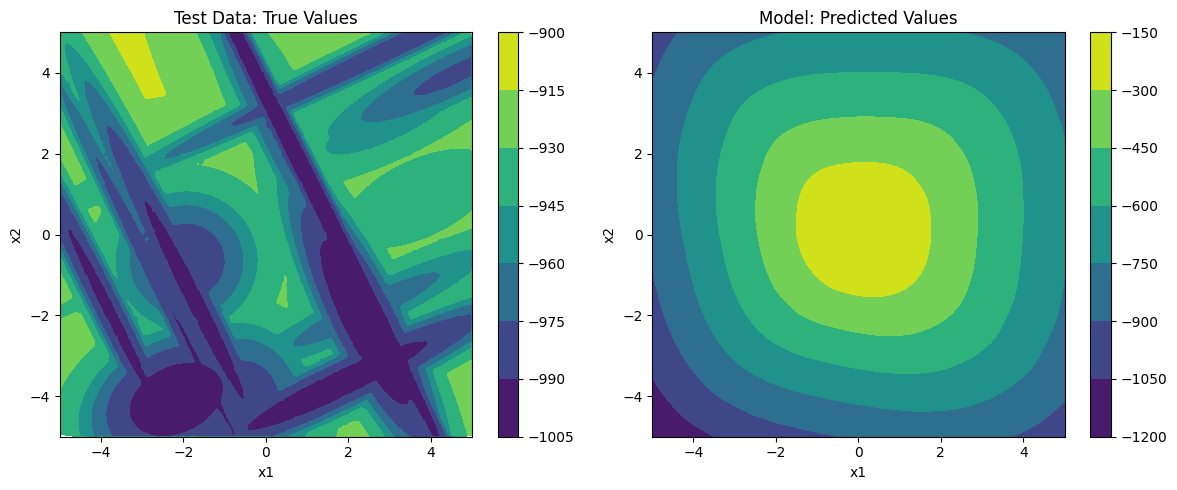

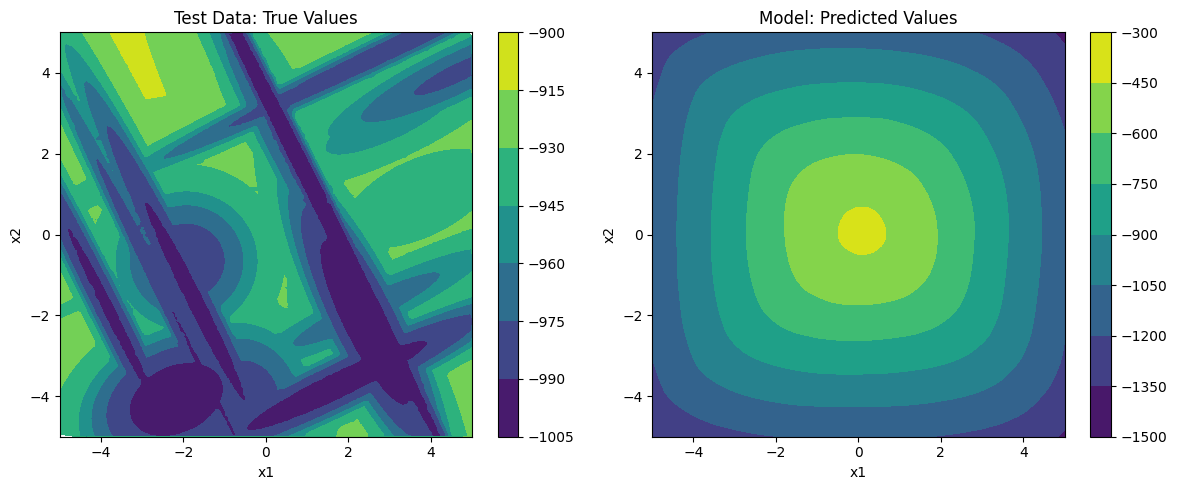

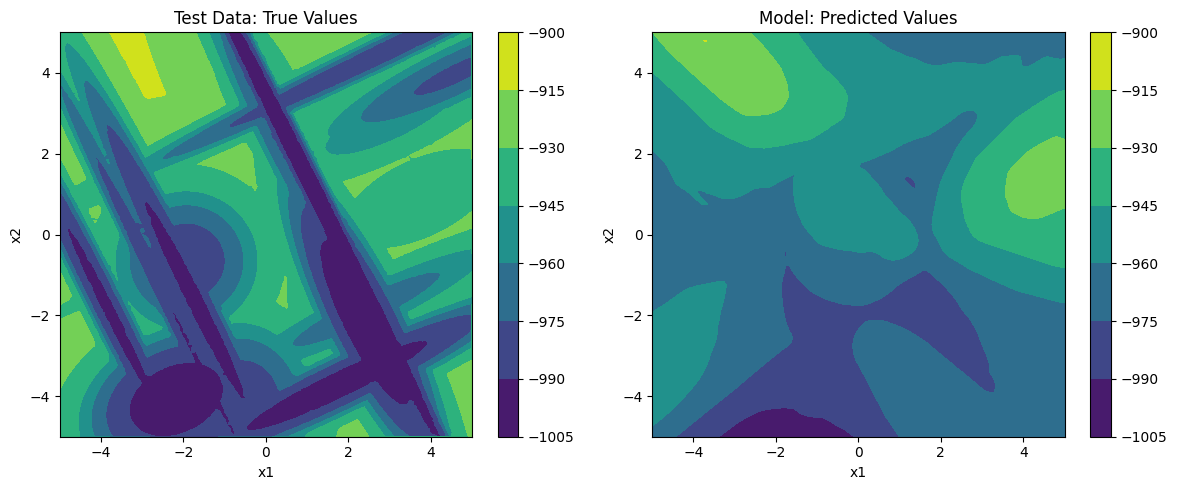

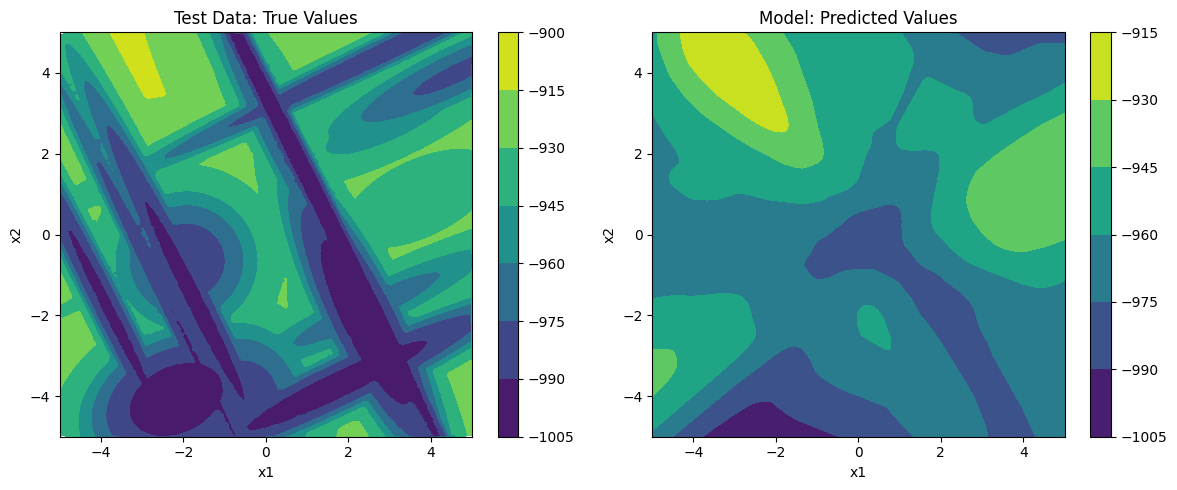

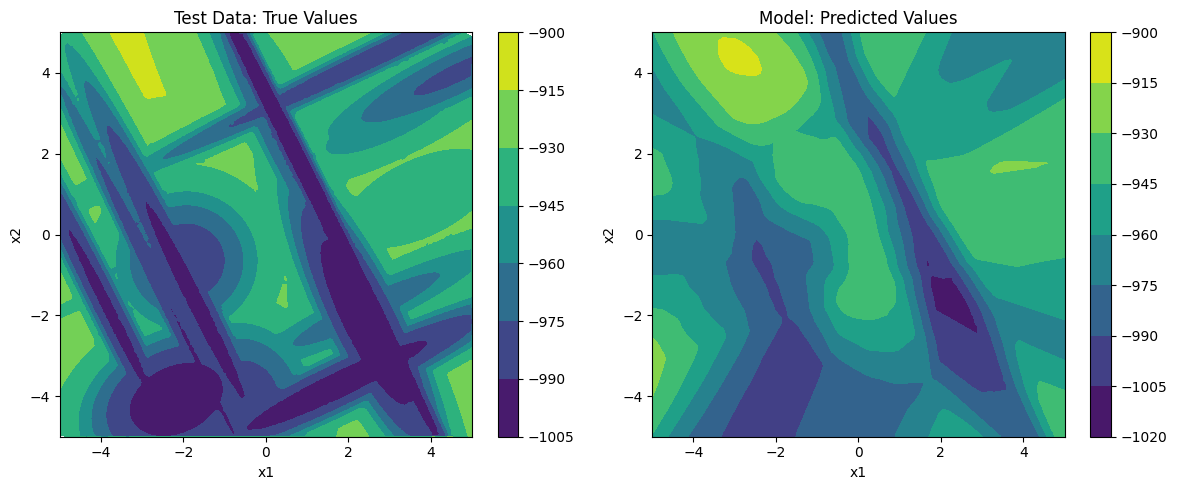

In [12]:
for _model, _test_dataloader in zip(models, test_dataloader_history):
  plot_contour_comparison(_model, _test_dataloader, device)

In [13]:
models_f1 = []
train_losses_history_f1 = []
val_losses_history_f1 = []
test_loss_history_f1 = []
train_dataloader_history_f1 = []
val_dataloader_history_f1 = []
test_dataloader_history_f1 = []

for train_perc in train_perc_values:
  print(f"Training with train_per={train_perc}")
  _train_dataloader, _val_dataloader, _test_dataloader = prepare_dataloaders(
    "./bbob_f001_i01_d02_samples.csv", train_perc=train_perc, val_perc=0.7-train_perc
  )

  _model, _train_losses, _val_losses, _test_loss = train_model(
      _train_dataloader, _val_dataloader, _test_dataloader
  )


  train_dataloader_history_f1.append(_train_dataloader)
  val_dataloader_history_f1.append(_val_dataloader)
  test_dataloader_history_f1.append(_test_dataloader)
  models_f1.append(_model)
  train_losses_history_f1.append(_train_losses)
  val_losses_history_f1.append(_val_losses)
  test_loss_history_f1.append(_test_loss)

  print(20*"=")

Training with train_per=0.001
Epoch 10/100, Train Loss: 7995.1992, Val Loss: 7918.1712
Epoch 20/100, Train Loss: 5567.7637, Val Loss: 5417.9486
Epoch 30/100, Train Loss: 2736.9080, Val Loss: 2594.8394
Epoch 40/100, Train Loss: 673.3636, Val Loss: 674.7296
Epoch 50/100, Train Loss: 334.9986, Val Loss: 451.5646
Epoch 60/100, Train Loss: 397.6218, Val Loss: 476.7564
Epoch 70/100, Train Loss: 283.3758, Val Loss: 382.7549
Epoch 80/100, Train Loss: 285.0321, Val Loss: 388.2742
Epoch 90/100, Train Loss: 270.6393, Val Loss: 368.9835
Epoch 100/100, Train Loss: 261.8152, Val Loss: 357.3448
Test Loss: 356.3548
Training with train_per=0.01
Epoch 10/100, Train Loss: 1313.6631, Val Loss: 982.6306
Epoch 20/100, Train Loss: 405.1328, Val Loss: 408.3978
Epoch 30/100, Train Loss: 347.4314, Val Loss: 347.0456
Epoch 40/100, Train Loss: 287.1353, Val Loss: 285.9936
Epoch 50/100, Train Loss: 221.8502, Val Loss: 220.2407
Epoch 60/100, Train Loss: 156.4352, Val Loss: 154.5991
Epoch 70/100, Train Loss: 96.8444

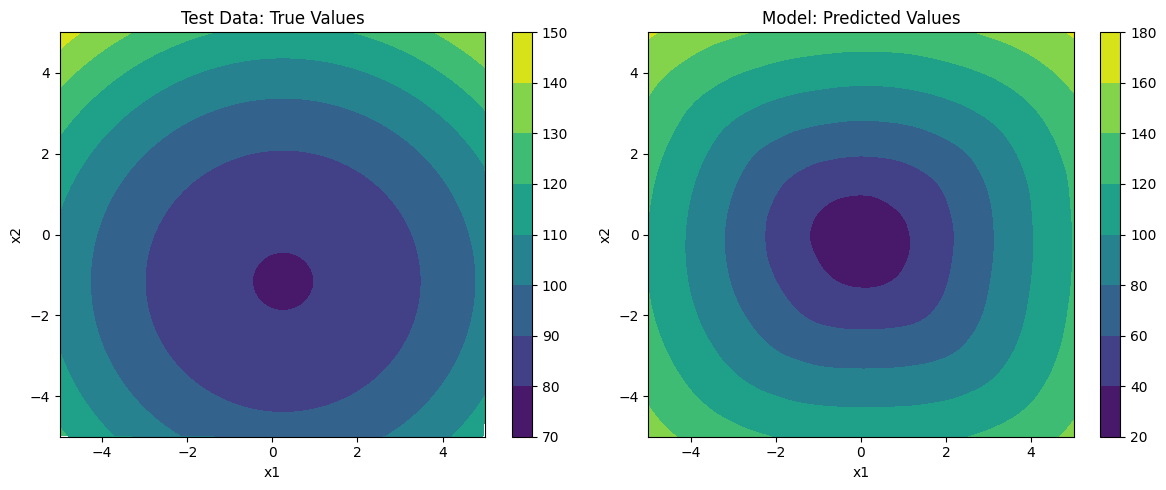

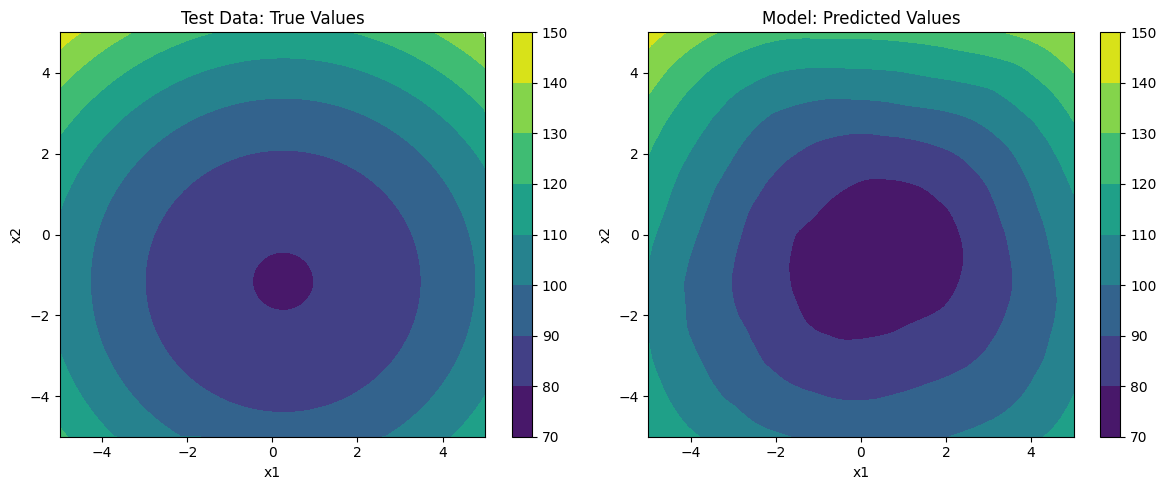

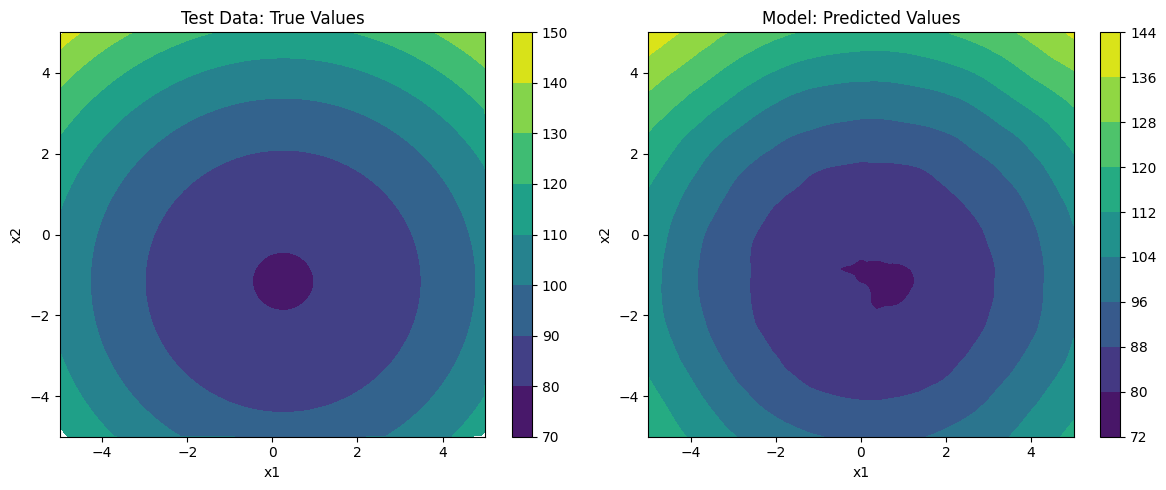

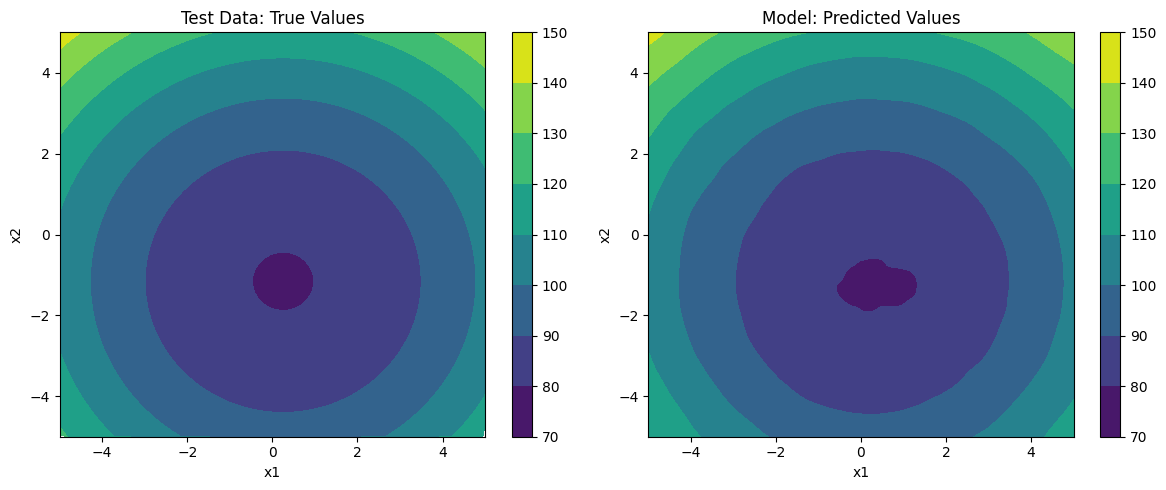

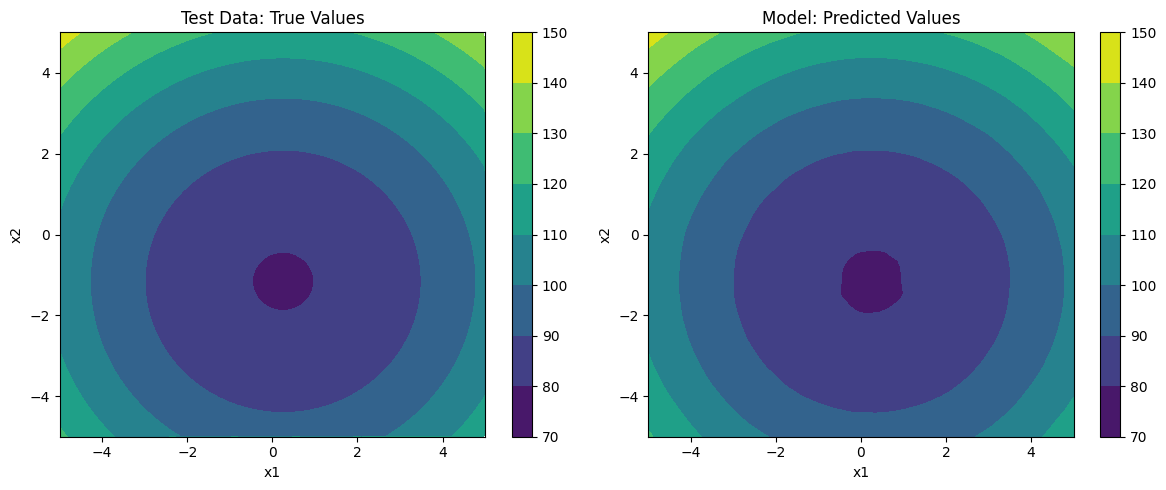

In [14]:
for _model, _test_dataloader in zip(models_f1, test_dataloader_history_f1):
  plot_contour_comparison(_model, _test_dataloader, device)

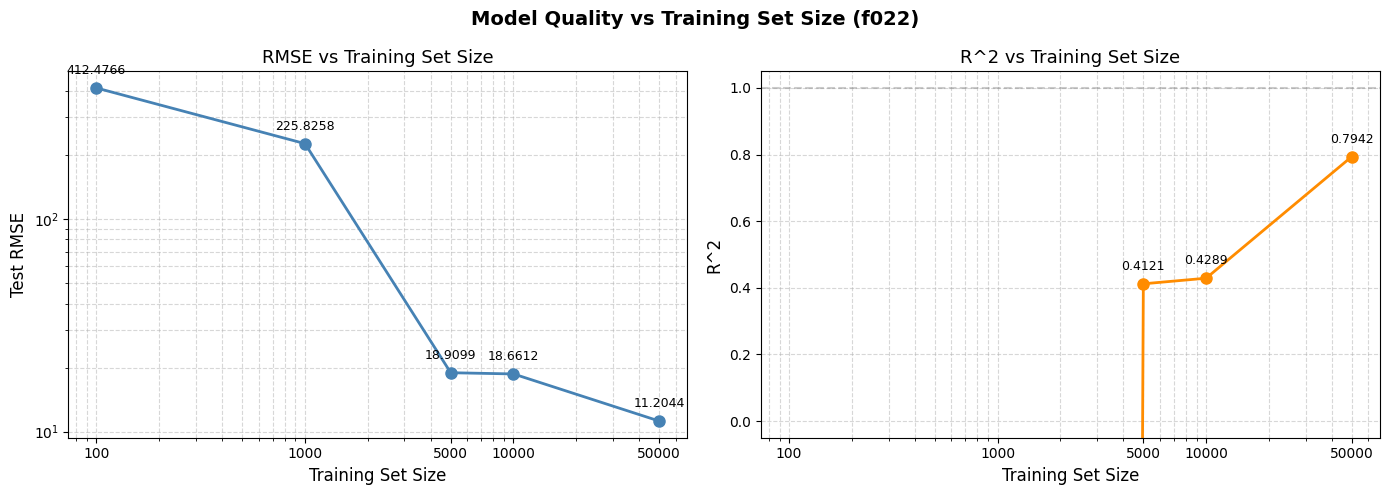

In [16]:
from sklearn.metrics import r2_score

test_r2_values = []

for model, test_dataloader in zip(models, test_dataloader_history):
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for inputs, targets in test_dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            all_preds.append(outputs.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    test_r2_values.append(r2_score(all_targets, all_preds))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE plot
test_rmse_values = [np.sqrt(loss) for loss in test_loss_history]
axes[0].plot(train_samples_values, test_rmse_values, marker='o', linewidth=2, markersize=8, color='steelblue')
for x, y in zip(train_samples_values, test_rmse_values):
    axes[0].annotate(f'{y:.4f}', (x, y), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Training Set Size', fontsize=12)
axes[0].set_ylabel('Test RMSE', fontsize=12)
axes[0].set_title('RMSE vs Training Set Size', fontsize=13)
axes[0].set_xticks(train_samples_values)
axes[0].get_xaxis().set_major_formatter(plt.ScalarFormatter())
axes[0].grid(True, which='both', linestyle='--', alpha=0.5)

# R^2 plot
axes[1].plot(train_samples_values, test_r2_values, marker='o', linewidth=2, markersize=8, color='darkorange')
for x, y in zip(train_samples_values, test_r2_values):
    axes[1].annotate(f'{y:.4f}', (x, y), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)
axes[1].set_xscale('log')
axes[1].set_xlabel('Training Set Size', fontsize=12)
axes[1].set_ylabel('R^2', fontsize=12)
axes[1].set_title('R^2 vs Training Set Size', fontsize=13)
axes[1].set_xticks(train_samples_values)
axes[1].get_xaxis().set_major_formatter(plt.ScalarFormatter())
axes[1].set_ylim(-0.05, 1.05)
axes[1].axhline(y=1.0, color='gray', linestyle='--', alpha=0.4)
axes[1].grid(True, which='both', linestyle='--', alpha=0.5)

plt.suptitle('Model Quality vs Training Set Size (f022)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('metrics_vs_training_size.png', dpi=150)
plt.show()

### Exercise 2: Optimization Robustness
- **Task:** Implement the `optimize_model` function to find inputs that minimize the model's output.
- **Instructions:**
  1. Execute the optimization process multiple times (e.g. 10 for each dataset) with different random starting points and record the best surrogate values.
  2. Create a histogram of the best `y` values across all optimization runs to visualize the distribution of results.
  3. Generate a contour plot showing the locations of the solutions found. Analyze the consistency of these solutions.
  4. Use `cocoex` to evaluate the true objective function at the solution points. Compare these values against the surrogate’s predicted values.

In [17]:
model = MLP().to(device)

optimize_model(
    model,
    num_steps=1000
)

(tensor([[0.1897, 5.0000]], device='cuda:0'),
 tensor([[-0.1780]], device='cuda:0'))

### Accessing Original COCO Benchmark Problems

The code below installs and imports the necessary packages to access the original COCO benchmark problems (f1 and f22).
This will allow us to compare our model's predictions with the true functions and evaluate optimization performance.

In [18]:
! pip install coco-experiment cocopp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 76.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 751.8/751.8 kB 58.7 MB/s eta 0:00:00
  Created wheel for cocopp: filename=cocopp-2.8.4-py3-none-any.whl size=8623346 sha256=5401ce46f909bfebefcc1b3b40b7f38d82df5c7e4607b67198d4a0c91b86257b
  Stored in directory: /root/.cache/pip/wheels/b3/a2/bf/20ee47958a5a6aaff8cc79d51d87658927d3a74769a59e58cc
Successfully built cocopp


In [19]:
from cocoex import Suite

function_id = 22  # Switch between 1 and 22 to change the function

suite = Suite(
    "bbob",
    "",
    f"function_indices: {function_id}, dimensions: 2 instance_indices: 1",
)
for function in suite:
    print(function.info)
    print("Function value at (0, 0):", function(np.array([0, 0])))

bbob_f022_i01_d02: a 2-dimensional single-objective problem (problem 315 of suite "b'bbob'" with name "BBOB suite problem f22 instance 1 in 2D")
Function value at (0, 0): -936.0557554469844


In [25]:
import cocoex
from tqdm import tqdm

num_runs = 10
all_best_x = []
all_best_y = []

for i, model in enumerate(models):
    run_x, run_y = [], []
    for _ in tqdm(range(num_runs)):
        best_x, best_y = optimize_model(model)
        run_x.append(best_x.cpu().numpy().flatten())
        run_y.append(best_y.item())
    all_best_x.append(run_x)
    all_best_y.append(run_y)
    print(f"Model {i+1} (n={train_samples_values[i]}): best_y min={min(run_y):.4f}, max={max(run_y):.4f}")

100%|██████████| 10/10 [00:16<00:00,  1.68s/it]


Model 1 (n=100): best_y min=-1133.3617, max=-407.3673


100%|██████████| 10/10 [00:14<00:00,  1.48s/it]


Model 2 (n=1000): best_y min=-1380.1635, max=-683.9121


100%|██████████| 10/10 [00:14<00:00,  1.50s/it]


Model 3 (n=5000): best_y min=-987.4951, max=-964.6934


100%|██████████| 10/10 [00:15<00:00,  1.58s/it]


Model 4 (n=10000): best_y min=-995.5696, max=-938.9635


100%|██████████| 10/10 [00:15<00:00,  1.50s/it]

Model 5 (n=50000): best_y min=-1005.0480, max=-949.6396


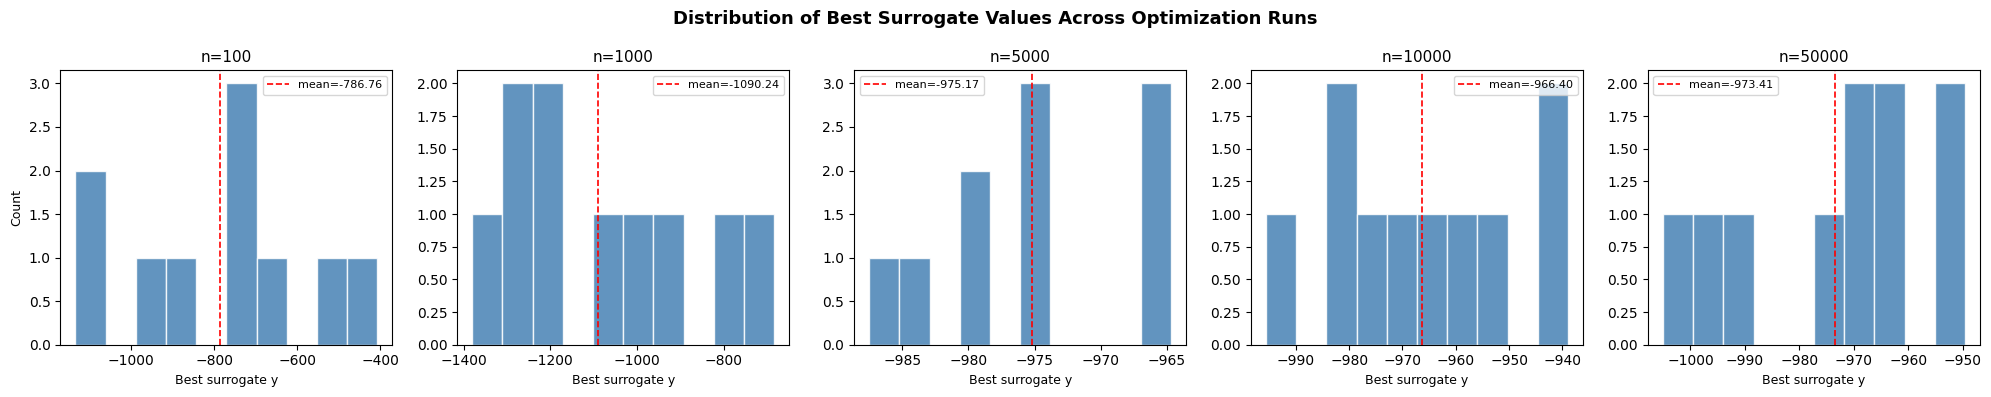

In [26]:
fig, axes = plt.subplots(1, len(models), figsize=(4 * len(models), 4), sharey=False)

for i, (ax, run_y) in enumerate(zip(axes, all_best_y)):
    ax.hist(run_y, bins=10, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(f'n={train_samples_values[i]}', fontsize=11)
    ax.set_xlabel('Best surrogate y', fontsize=9)
    ax.set_ylabel('Count' if i == 0 else '', fontsize=9)
    ax.axvline(np.mean(run_y), color='red', linestyle='--', linewidth=1.2, label=f'mean={np.mean(run_y):.2f}')
    ax.legend(fontsize=8)

fig.suptitle('Distribution of Best Surrogate Values Across Optimization Runs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('histogram_best_y.png', dpi=150)
plt.show()

In [29]:
def plot_contour_comparison_with_solution_points(
    model: nn.Module,
    test_dataloader: DataLoader,
    device: torch.device,
    solution_points: np.ndarray | None = None,
) -> None:
    test_inputs_list = []
    test_targets_list = []

    for inputs, targets in test_dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        test_inputs_list.append(inputs.cpu().numpy())
        test_targets_list.append(targets.cpu().numpy())

    test_inputs = np.vstack(test_inputs_list)
    test_targets = np.concatenate(test_targets_list)

    x1_min, x1_max = test_inputs[:, 0].min(), test_inputs[:, 0].max()
    x2_min, x2_max = test_inputs[:, 1].min(), test_inputs[:, 1].max()
    x1_vals = np.linspace(x1_min, x1_max, 100)
    x2_vals = np.linspace(x2_min, x2_max, 100)
    X1, X2 = np.meshgrid(x1_vals, x2_vals)

    grid_points = np.column_stack((X1.flatten(), X2.flatten()))
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32, device=device)

    model.eval()
    with torch.no_grad():
        predictions = model(grid_tensor).cpu().numpy().flatten()
    Z_pred = predictions.reshape(X1.shape)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    true_contour = ax1.tricontourf(test_inputs[:, 0], test_inputs[:, 1], test_targets.reshape(-1))
    ax1.set_title("Test Data: True Values")
    ax1.set_xlabel("x1")
    ax1.set_ylabel("x2")
    plt.colorbar(true_contour, ax=ax1)

    pred_contour = ax2.contourf(X1, X2, Z_pred)
    ax2.set_title("Model: Predicted Values")
    ax2.set_xlabel("x1")
    ax2.set_ylabel("x2")
    plt.colorbar(pred_contour, ax=ax2)

    if solution_points is not None:
        for ax in (ax1, ax2):
            ax.scatter(
                solution_points[:, 0], solution_points[:, 1],
                c='red', s=80, zorder=5, label='found minima',
                edgecolors='white', linewidths=0.8
            )
            ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

n=100


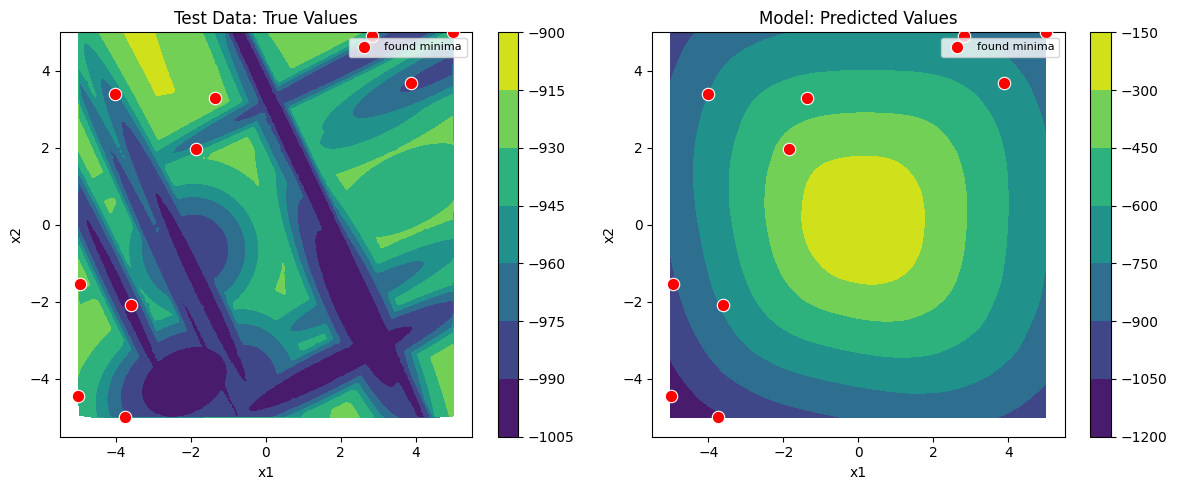

n=1000


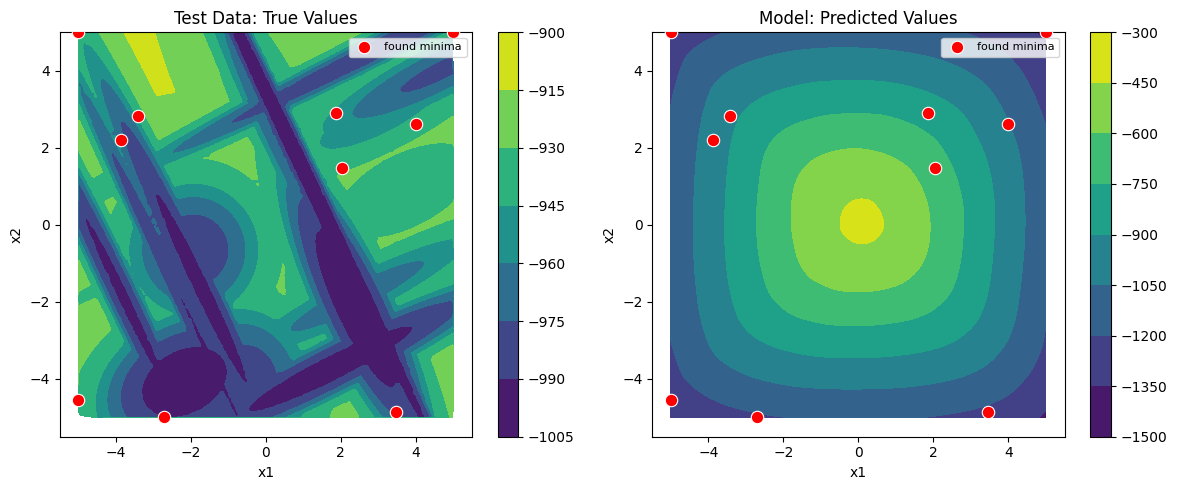

n=5000


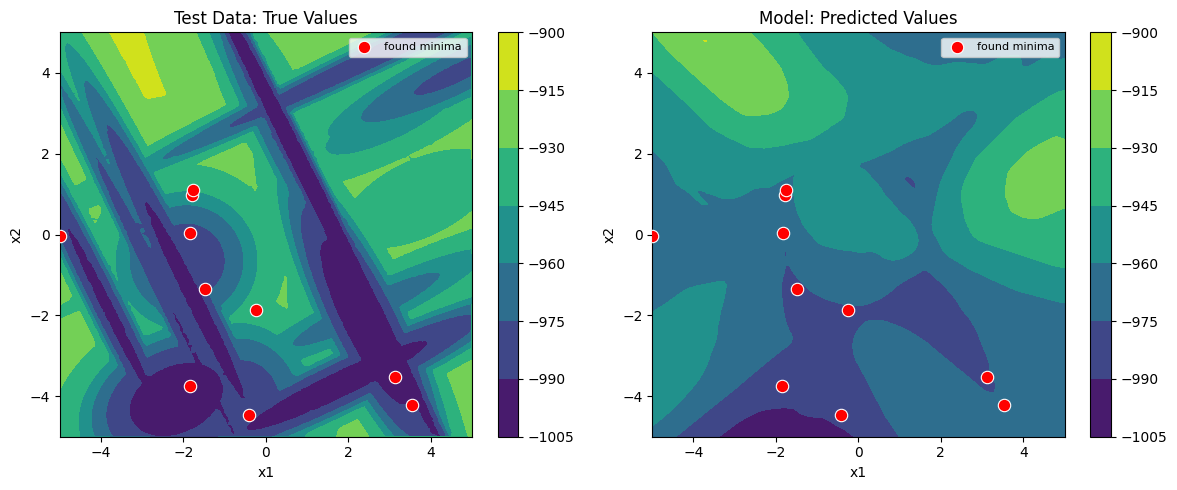

n=10000


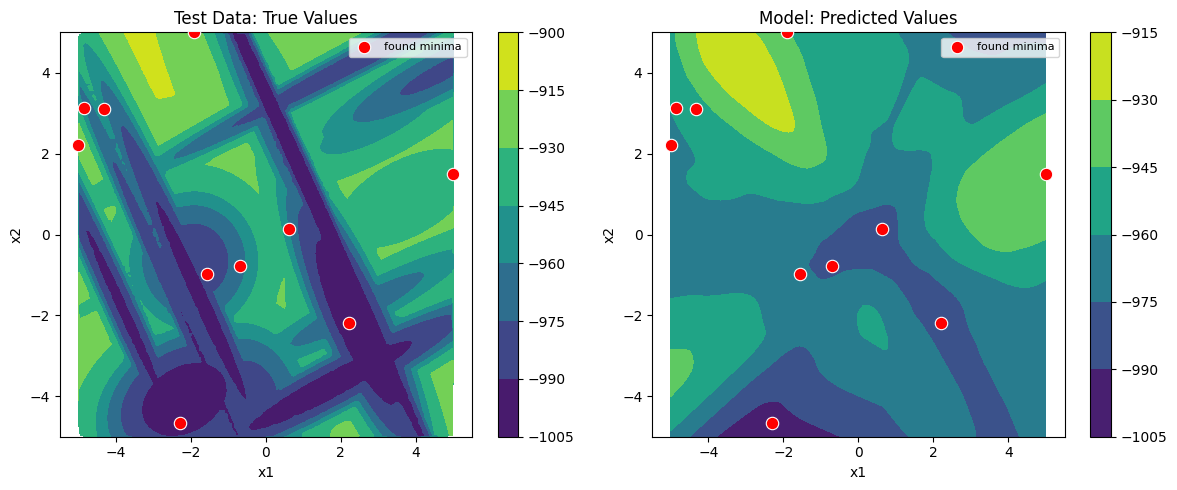

n=50000


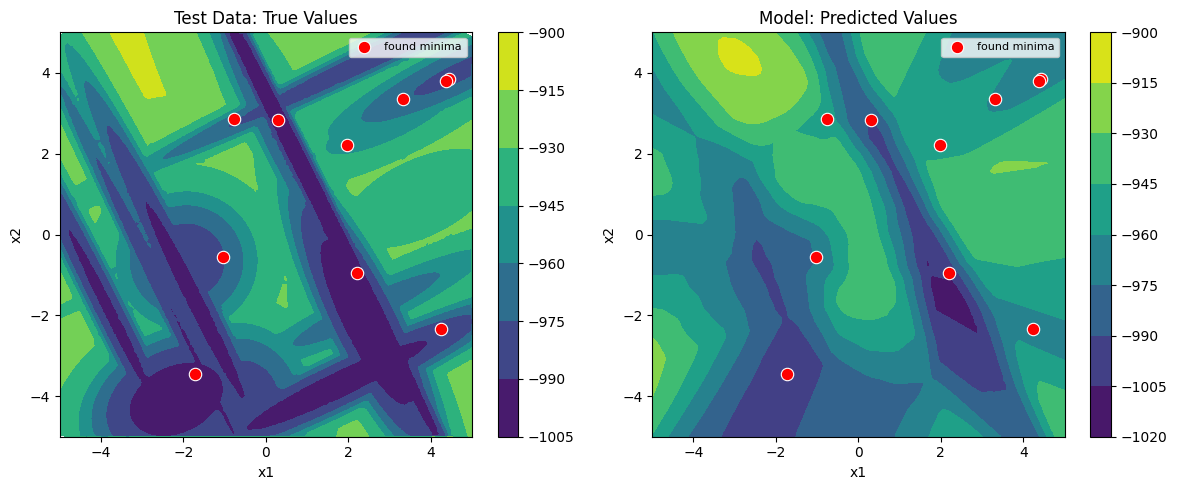

In [31]:
for i, (model, test_dataloader) in enumerate(zip(models, test_dataloader_history)):
    solution_points = np.array(all_best_x[i])
    print(f"n={train_samples_values[i]}")
    plot_contour_comparison_with_solution_points(model, test_dataloader, device, solution_points=solution_points)

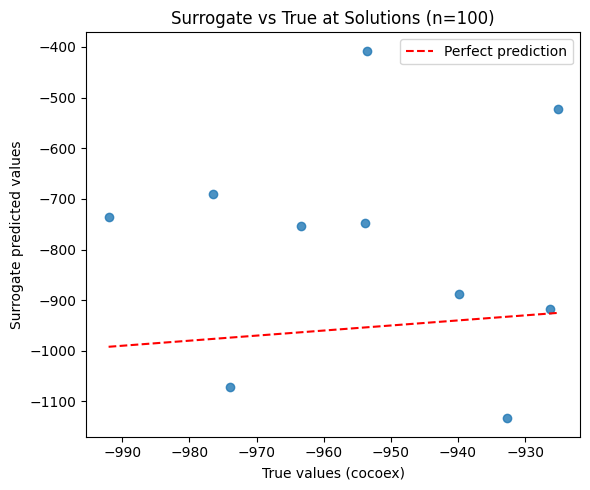

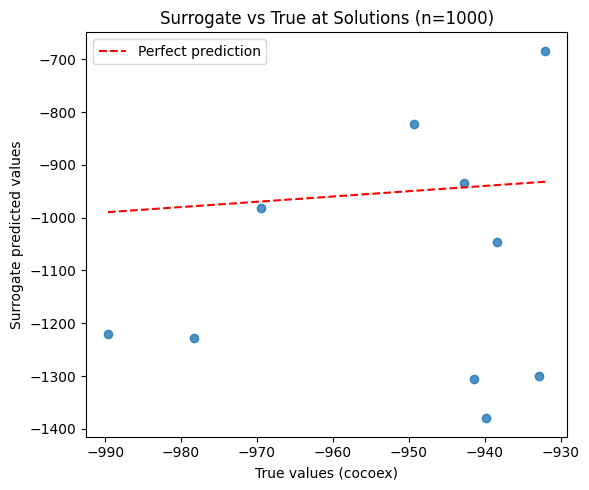

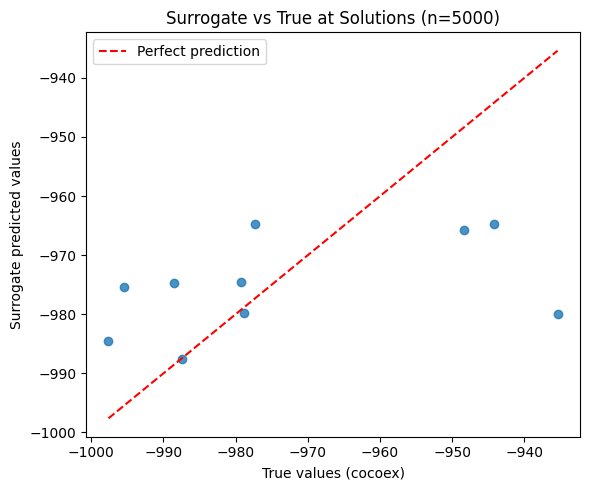

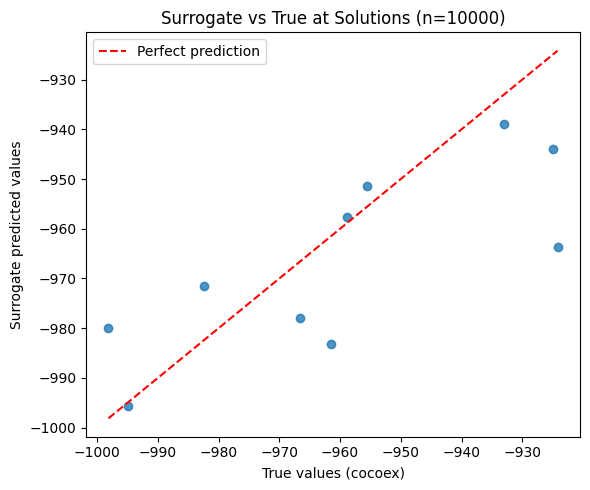

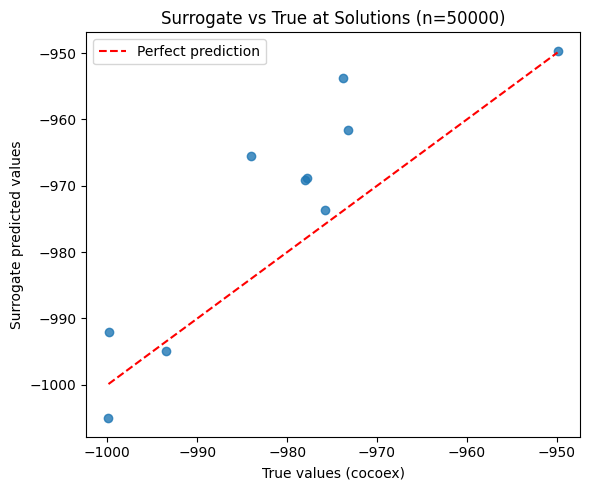

In [33]:
import cocoex

suite = cocoex.Suite("bbob", "", "dimensions:2 instance_indices:1")
problem = suite.get_problem_by_function_dimension_instance(22, 2, 1)

for i, (model, test_dataloader) in enumerate(zip(models, test_dataloader_history)):
    solution_points = np.array(all_best_x[i])  # (num_runs, 2)
    surrogate_y = np.array(all_best_y[i])
    true_y = np.array([problem(x) for x in solution_points])

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(true_y, surrogate_y, alpha=0.8)
    ax.plot(
        [true_y.min(), true_y.max()],
        [true_y.min(), true_y.max()],
        "r--", label="Perfect prediction"
    )
    ax.set_xlabel("True values (cocoex)")
    ax.set_ylabel("Surrogate predicted values")
    ax.set_title(f"Surrogate vs True at Solutions (n={train_samples_values[i]})")
    ax.legend()
    plt.tight_layout()
    plt.show()